In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import torch
import numpy as np
import pandas as pd
import json
import time
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import RobertaForSequenceClassification, RobertaTokenizer
from sentence_transformers import SentenceTransformer, util
from google import genai
from dotenv import load_dotenv
from data_loader import load_edos_data, TASK_A_ID2LABEL, TASK_B_ID2LABEL

DATA_DIR='../data/'
RESULTS_DIR='../results/'
MODELS_DIR='../models/'
KG_DIR='../kg/'
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\Users\Ashwin Nair\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
load_dotenv('../.env')
GEMINI_API_KEY=os.environ.get('GEMINI_API_KEY')
if not GEMINI_API_KEY:
    raise ValueError('GEMINI_API_KEY not found in .env file')

client=genai.Client(api_key=GEMINI_API_KEY) ## Calling the Gemini API
GEMINI_MODEL='gemini-2.5-flash-lite' ## Model Name

time.sleep(3)
response=client.models.generate_content(model=GEMINI_MODEL, contents='Reply with OK only.') ## Response from Gemini to see if its working correctly or not
print(f'Gemini API working: {response.text.strip()}')

Gemini API working: OK


In [3]:
def load_roberta(task: str): ## Load fine-tuned RoBERTa model saved from Notebook 02.
    model_path=os.path.join(MODELS_DIR, f'roberta_task_{task}')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model not found at {model_path}. Run Notebook 02 first.')
    tokenizer=RobertaTokenizer.from_pretrained('roberta-base') ## Roberta Tokenizer
    model=RobertaForSequenceClassification.from_pretrained(model_path)
    model.to(DEVICE)
    model.eval()
    print(f'Loaded RoBERTa Task {task} from {model_path}')
    return model, tokenizer

roberta_a, tokenizer_a = load_roberta('A') ## Loading Roberta Task A
roberta_b, tokenizer_b = load_roberta('B') ## Loading Roberta Task B

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5432.93it/s]


Loaded RoBERTa Task A from ../models/roberta_task_A


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4562.95it/s]


Loaded RoBERTa Task B from ../models/roberta_task_B


In [4]:
kg_path = os.path.join(KG_DIR, 'sexism_kg_v2.json') ## loading our new knowledge graph with restricted relations
with open(kg_path, 'r') as f:
    kg = json.load(f)

all_triples=kg['triples']
entity_index=kg['entity_index']
relation_index=kg['relation_index']

## Knowledge Graph Summary
print(f'KG v2 loaded:')
print(f'Total triples:{len(all_triples)}')
print(f'Unique entities:{len(entity_index)}')
print(f'Unique relations:{len(relation_index)}')

KG v2 loaded:
Total triples:5256
Unique entities:4994
Unique relations:6


In [5]:
# Task A is confidence-gated at 0.80 to match Proposed A.
# Task B is ungated - LLM runs on every post for full explanation coverage.
CONFIDENCE_THRESHOLD_A = 0.80

MAX_TRIPLES_TO_RETRIEVE=3 ## Number of relevant triplets to retrieve
SIMILARITY_THRESHOLD=0.3  # minimum cosine similarity to retrieve a triple
SEMANTIC_MODEL_NAME='all-MiniLM-L6-v2' # fast, lightweight, good quality

print('Configuration loaded.')
print(f'Semantic model: {SEMANTIC_MODEL_NAME}')
print(f'Task A threshold: {CONFIDENCE_THRESHOLD_A} | Task B: ungated')
print(f'Similarity threshold: {SIMILARITY_THRESHOLD}')
print(f'Max triples per post: {MAX_TRIPLES_TO_RETRIEVE}')

Configuration loaded.
Semantic model: all-MiniLM-L6-v2
Task A threshold: 0.8 | Task B: ungated
Similarity threshold: 0.3
Max triples per post: 3


In [6]:
print('Loading sentence transformer model')
sem_model=SentenceTransformer(SEMANTIC_MODEL_NAME) ## Loads all-MiniLM-L6-v2 - a lightweight but high quality sentence embedding mode

# Convert each triple to a text representation for embedding
def triple_to_text(triple: dict) -> str: ## Convert a triple dict to a readable sentence for embedding.
    return f"{triple['subject']} {triple['relation'].replace('_', ' ').lower()} {triple['object']}"

# Embed all triples - done once at startup
print(f'Embedding {len(all_triples)} triples')
triple_texts=[triple_to_text(t) for t in all_triples]
triple_embeddings=sem_model.encode(triple_texts,batch_size=256,show_progress_bar=True,convert_to_tensor=True,device=DEVICE) ## Create embeddings

print(f'Triple embeddings shape: {triple_embeddings.shape}')
print('Done.')

# Show example triple texts
print('\nSample triple texts:')
for i in range(3):
    print(f'{triple_texts[i]}')

Loading sentence transformer model


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4289.08it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 5256 triples


Batches: 100%|██████████| 21/21 [00:03<00:00,  6.35it/s]

Triple embeddings shape: torch.Size([5256, 384])
Done.

Sample triple texts:
hot girls expressed animosity towards easy
asian ladies framed as inferior 5/10
asian ladies framed as inferior get laid after spending years pretending


In [7]:
def roberta_predict(text: str, model, tokenizer, id2label: dict) -> tuple: ## Get RoBERTa prediction, confidence and all class probabilities and return predicted_label, confidence, all_probs
    encoding = tokenizer(text, truncation=True, padding='max_length',max_length=128, return_tensors='pt').to(DEVICE) ## Move the encoding to the specified device
    with torch.no_grad(): ## Disable gradient calculation for inference 
        outputs=model(**encoding) ## Get model outputs
        probs=torch.softmax(outputs.logits, dim=-1).squeeze() ## Compute probabilities using softmax

    pred_id=torch.argmax(probs).item() ## Get the predicted class ID
    confidence=probs[pred_id].item() ## Get the confidence score for the predicted class
    label=id2label[pred_id] ## Get the label corresponding to the predicted class ID
    all_probs={id2label[i]: round(probs[i].item(), 4) for i in range(len(probs))}  
    return label, confidence, all_probs

In [8]:
def retrieve_triples_semantic(text: str, roberta_category: str, task: str) -> list:
    """
    1. Retrieve KG triples using pure semantic similarity.
    2. No category pre-filtering - retrieval is fully independent of RoBERTa's prediction unlike what we did in Task A
    3. The most semantically similar triples are returned regardless of relation or category.
    """
    # 1. Embed the test post as a vector
    post_embedding=sem_model.encode(text, convert_to_tensor=True, device=DEVICE)

    # 2. Compute cosine similarity between post and all triple embeddings
    similarities=util.cos_sim(post_embedding, triple_embeddings)[0]

    # 3. Sort all triples by similarity descending - no category pre-filtering since retrieval is fully independent of RoBERTa's predicted category
    sorted_indices=torch.argsort(similarities, descending=True).tolist()
    retrieved=[]
    seen_triples=set()  ## Track seen triples to avoid duplicates
    for idx in sorted_indices:
        if len(retrieved)>=MAX_TRIPLES_TO_RETRIEVE: ## Stop when we have n triples
            break

        sim=similarities[idx].item()
        if sim<SIMILARITY_THRESHOLD: ## Stop if similarity drops below threshold
            break

        triple=all_triples[idx]
        key=(triple['subject'], triple['relation'], triple['object'])

        if key in seen_triples: ## Skip duplicate triples
            continue

        seen_triples.add(key)
        retrieved.append({**triple, 'similarity': sim}) ## Add triple with similarity score

    return retrieved

In [9]:
def format_kg_context(triples: list) -> str: ## Format retrieved triples with similarity scores for the LLM prompt.
    if not triples:
        return "No relevant knowledge found."
    lines=[]
    for t in triples:
        sim_str=f"(relevance: {t['similarity']})" if 'similarity' in t else ""
        lines.append(f"-({t['subject']}, {t['relation']}, {t['object']}){sim_str}")
    return '\n'.join(lines)

In [10]:
TASK_A_PROMPT_KG = """You are an expert in detecting sexist content on social media.

A classifier has analysed the post below. Your job is to confirm or correct its prediction.

Post: "{text}"

Classifier prediction: {prediction} (confidence: {confidence:.1%})
Classifier probabilities: {probs}

Patterns from semantically similar posts already labelled SEXIST:
{kg_context}

IMPORTANT: These patterns were drawn only from posts already labelled sexist. Their
presence does NOT by itself mean this post is sexist - neutral posts can express
similar themes. Use them only where the post genuinely expresses the pattern shown.

The classifier is accurate. Override it only with clear evidence it is wrong.

Respond with ONLY one of these two labels (no explanation):
not sexist
sexist"""


TASK_B_PROMPT_KG = """You are an expert in categorising sexist content on social media.

This post has already been identified as sexist. Your job is to confirm or correct the
classifier's judgement about which category of sexism it belongs to.

Post: "{text}"

Classifier prediction: {prediction} (confidence: {confidence:.1%})
Classifier probabilities: {probs}

Relevant knowledge from semantically similar training posts:
{kg_context}

Categories:
- threats - an explicit or implied threat of violence, harm, or non-consensual action
  against women, or incitement of others to carry one out
- derogation - insults, slurs, objectification, or statements portraying women as
  inferior, worthless, or contemptible
- animosity - expressions of hostility, resentment, or hatred towards women or
  feminists, including sarcasm and mockery, without a specific threat
- prejudiced discussions - an explicit ideological or pseudo-scientific argument that
  women as a group should occupy a particular role or have restricted rights. This
  requires an argumentative or declarative claim, not merely a hostile opinion.

Tie-breaking rules:
- If the post is primarily an insult or slur, choose derogation.
- If the post is primarily contempt, mockery, or resentment, choose animosity.
- Choose prejudiced discussions ONLY when the post makes an actual argument or
  assertion about the role, rights, or nature of women as a group.
- Do not choose prejudiced discussions merely because a post implies something about
  women in general - most sexist posts do.

The classifier is generally accurate. Override it only when you have clear evidence
from the post itself that a different category fits better.

Respond with ONLY one of these exact words or phrases (no explanation, no numbers):
threats
derogation
animosity
prejudiced discussions"""

In [11]:
TASK_B_SHORT_TO_FULL = { ## Handling inconsistent possible Gemini Outputs
    'threats':'1. threats, plans to harm and incitement',
    'threat':'1. threats, plans to harm and incitement',
    'derogation':'2. derogation',
    'animosity':'3. animosity',
    'animosty':'3. animosity',
    'prejudiced discussions': '4. prejudiced discussions',
    'prejudiced':'4. prejudiced discussions',
}

In [12]:
def llm_reason_with_kg(text: str, roberta_label: str, confidence: float,all_probs: dict, kg_triples: list,task: str, max_retries: int = 3):
    """
    Call Gemini with post + RoBERTa prediction + KG triples.
    Returns final label or None if all retries fail.
    """
    kg_context = format_kg_context(kg_triples) ## Format the retrieved triples into a readable string for the LLM prompt
    if task=='A': ### If the task is A, use the Task A prompt
        prompt=TASK_A_PROMPT_KG.format(text=text, prediction=roberta_label,confidence=confidence, probs=all_probs,kg_context=kg_context)
        valid_labels={'not sexist', 'sexist'}
    else: ### If the task is B, use the Task B prompt
        prompt=TASK_B_PROMPT_KG.format(text=text, prediction=roberta_label,confidence=confidence, probs=all_probs,kg_context=kg_context)
        valid_labels={
            '1. threats, plans to harm and incitement',
            '2. derogation', '3. animosity',
            '4. prejudiced discussions'
        }
    for attempt in range(max_retries): ### Retry loop for calling the Gemini model
        try:
            response=client.models.generate_content(model=GEMINI_MODEL, contents=prompt) ## Call the Gemini model with the prompt
            if response is None or not hasattr(response, 'text') or response.text is None: ### Check if the response is empty or invalid
                raise ValueError('Empty response from Gemini')
            llm_label=response.text.strip().lower()
            if llm_label in valid_labels:
                return llm_label
            if task=='B': ## If the task is B, check for short forms of the labels
                if llm_label in TASK_B_SHORT_TO_FULL:
                    return TASK_B_SHORT_TO_FULL[llm_label]
                for short, full in TASK_B_SHORT_TO_FULL.items():
                    if short in llm_label:
                        return full
            if task == 'A': ## If the task is A, check if any valid label is a substring of the LLM response
                for valid in valid_labels:
                    if valid in llm_label:
                        return valid
            print(f' Unrecognised response: "{llm_label}" - falling back to RoBERTa')
            return roberta_label.lower()

        except Exception as e: ## Handle exceptions during the Gemini API call
            error_str = str(e)
            if '429' in error_str or '503' in error_str: ## If the error is a rate limit or server busy error, wait longer before retrying
                wait = 60 * (attempt + 1)
                print(f'Server busy - waiting {wait}s (retry {attempt+1}/{max_retries})')
                time.sleep(wait)
            elif attempt < max_retries-1:
                print(f'Attempt {attempt+1} failed: {e} - retrying in 15s')
                time.sleep(15)
            else:
                print(f'Failed after {max_retries} attempts: {e}')

    print(f'All retries failed - falling back to RoBERTa')
    return roberta_label.lower()

In [13]:
def run_proposed_bc(task: str, sample_size: int = None):
    """
    Proposed Model B+C pipeline:
    RoBERTa → semantic KG retrieval -> LLM reasoning
    No confidence threshold.
    Task A: LLM called when semantically similar triples found
    Task B: LLM called for every post (explainability for all)
    Always falls back to RoBERTa if LLM fails.
    """
    print(f'Proposed Model B+C - RoBERTa + KG v2 + LLM - Task {task}')
    print(f'KG: sexism_kg_v2.json | Retrieval: semantic similarity')
    print(f'Threshold: None | Fallback: RoBERTa')

    _, _, test_df = load_edos_data(DATA_DIR, task=task)
    if sample_size: ## If a sample size is specified, take only the first N samples from the test set
        test_df=test_df.head(sample_size)
        print(f'Running on {sample_size} samples (test mode)')
    else:
        print(f'Running on full test set ({len(test_df)} samples)')

    if task == 'A':
        model, tokenizer, id2label = roberta_a, tokenizer_a, TASK_A_ID2LABEL
    else:
        model, tokenizer, id2label = roberta_b, tokenizer_b, TASK_B_ID2LABEL

    # Checkpoint
    checkpoint_path = os.path.join(RESULTS_DIR, f'task_{task}_proposedBC_checkpoint.json')
    if os.path.exists(checkpoint_path) and not sample_size: ## Define the path for saving the checkpoint file
        with open(checkpoint_path, 'r') as f:
            checkpoint=json.load(f)
        true_labels=checkpoint['true_labels']
        roberta_labels=checkpoint['roberta_labels']
        final_labels=checkpoint['final_labels']
        start_idx=len(true_labels) ## Set the starting index for resuming from the checkpoint
        print(f'Resuming from checkpoint at index {start_idx}/{len(test_df)}') ## Print the index from which we are resuming
    else: ## If no checkpoint exists or we are in test mode, initialize empty lists for labels and set the starting index to 0
        true_labels=[]
        roberta_labels=[]
        final_labels=[]
        start_idx=0

    ## Counters
    llm_called=0  # posts that went through LLM
    llm_override=0  # times LLM changed RoBERTa's prediction
    kg_found=0  # posts where KG triples were retrieved
    kg_not_found=0  # posts where no KG triples found

    print('\nRunning pipeline')
    for i, (_, row) in enumerate(test_df.iterrows()): ## Iterate over the test DataFrame rows
        if i<start_idx:
            continue
        if i%100 == 0:
            print(f'Progress: {i}/{len(test_df)} | LLM called: {llm_called} | KG hits: {kg_found}')

        text=row['text']
        true_label=row['label']

        # Step 1: RoBERTa prediction
        r_label, r_conf, r_probs = roberta_predict(text, model, tokenizer, id2label)

        # Step 2: Semantic KG retrieval
        kg_triples = retrieve_triples_semantic(text, r_label, task) ## Retrieve relevant triples from the knowledge graph based on the text and RoBERTa's predicted label

        if task == 'A':
            ## Task A: gated on RoBERTa confidence at 0.80, matching Proposed A.
            ## Triple presence is not a usable gate - the KG holds only sexist posts,
            ## so retrieval fires on nearly every post regardless of true label.
            if r_conf < CONFIDENCE_THRESHOLD_A:
                if kg_triples:
                    kg_found += 1
                else:
                    kg_not_found += 1
                llm_called += 1
                final_label = llm_reason_with_kg(text, r_label, r_conf, r_probs, kg_triples, task)
                if final_label != r_label.lower():
                    llm_override += 1
                time.sleep(2)
            else:
                ## RoBERTa confident - use directly, no LLM call
                final_label = r_label.lower()

        else:
            # Task B: call LLM for every post - explainability for all
            if kg_triples:
                kg_found += 1
            else:
                kg_not_found += 1

            llm_called += 1
            final_label = llm_reason_with_kg(text, r_label, r_conf, r_probs, kg_triples, task)
            if final_label != r_label.lower():
                llm_override += 1
            time.sleep(2)

        true_labels.append(true_label)
        roberta_labels.append(r_label.lower())
        final_labels.append(final_label)

        # Save checkpoint every 100 samples
        if not sample_size and i % 100 == 0:
            with open(checkpoint_path, 'w') as f:
                json.dump({
                    'true_labels':    true_labels,
                    'roberta_labels': roberta_labels,
                    'final_labels':   final_labels
                }, f)

    # Final checkpoint
    if not sample_size:
        with open(checkpoint_path, 'w') as f:
            json.dump({
                'true_labels':    true_labels,
                'roberta_labels': roberta_labels,
                'final_labels':   final_labels
            }, f)
        print('Final checkpoint saved.')

    print(f'\nPipeline complete:')
    print(f'Total samples:{len(true_labels)}')
    print(f'LLM called:{llm_called}')
    print(f'KG triples found:{kg_found}')
    print(f'KG triples not found:{kg_not_found}')
    print(f'LLM overrode RoBERTa:{llm_override}')
    print(f'RoBERTa used directly:{len(true_labels) - llm_called}')

    return true_labels, roberta_labels, final_labels

In [14]:
def evaluate_proposed(true_labels, roberta_labels, final_labels,task: str, model_name: str = 'Proposed Model B+C'): ## Evaluate proposed model vs RoBERTa baseline
    if task == 'A':
        label_names = ['not sexist', 'sexist']
    else:
        label_names = [
            '1. threats, plans to harm and incitement',
            '2. derogation', '3. animosity',
            '4. prejudiced discussions'
        ]
    print(f'Evaluation - {model_name} - Task {task}')
    print('\n RoBERTa Only (Baseline 1)')
    r_report = classification_report(true_labels, roberta_labels,labels=label_names, digits=4, zero_division=0) ## Classification report for Roberta
    print(r_report)

    print(f'\n {model_name}')
    p_report = classification_report(true_labels, final_labels,labels=label_names, digits=4, zero_division=0) ## Classification report for Proposed B+C
    print(p_report)

    # Save report
    safe_name=model_name.lower().replace(' ', '_').replace('+', '')
    report_path=os.path.join(RESULTS_DIR, f'task_{task}_{safe_name}_results.txt')
    with open(report_path, 'w') as f:
        f.write(f'{model_name} - Task {task}\n\n')
        f.write('RoBERTa Only:\n')
        f.write(r_report)
        f.write(f'\n{model_name}:\n')
        f.write(p_report)
    print(f'Report saved to {report_path}')

    # Side by side confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cm_r = confusion_matrix(true_labels, roberta_labels, labels=label_names)
    sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues',xticklabels=label_names, yticklabels=label_names, ax=axes[0]) ## Confusion Matrix for Roberta
    axes[0].set_title(f'RoBERTa Only - Task {task}', fontsize=13)
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=30)

    cm_p = confusion_matrix(true_labels, final_labels, labels=label_names)
    sns.heatmap(cm_p, annot=True, fmt='d', cmap='Greens',xticklabels=label_names, yticklabels=label_names, ax=axes[1]) ## Confusion Matrix for Proposed A
    axes[1].set_title(f'{model_name} - Task {task}', fontsize=13)
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=30)
    plt.suptitle(f'{model_name} - Task {task}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    cm_path = os.path.join(RESULTS_DIR, f'task_{task}_{safe_name}_confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved to {cm_path}')

    # Summary metrics
    _, _, r_f1, _ = precision_recall_fscore_support(true_labels, roberta_labels, average='macro', zero_division=0)
    _, _, p_f1, _ = precision_recall_fscore_support(true_labels, final_labels, average='macro', zero_division=0)
    delta = p_f1 - r_f1

    print(f'\nMacro F1 Comparison - Task {task}:')
    print(f' RoBERTa only:{r_f1}')
    print(f'{model_name}:{p_f1}')
    print(f'Delta:{delta} ({"improvement" if delta > 0 else "regression"})')

    return {'roberta_f1': r_f1, 'proposed_f1': p_f1, 'delta': delta}

In [15]:
true_a_test, rob_a_test, prop_a_test = run_proposed_bc(task='A', sample_size=20) ## Testing the model on 20 samples
print('\nSample predictions:')
for true, rob, prop in zip(true_a_test, rob_a_test, prop_a_test):
    match='O' if prop == true else '✗'
    changed='(KG+LLM)' if rob != prop else '(RoBERTa)'
    print(f'{match} True: {true} RoBERTa: {rob} Final: {prop} {changed}')

Proposed Model B+C - RoBERTa + KG v2 + LLM - Task A
KG: sexism_kg_v2.json | Retrieval: semantic similarity
Threshold: None | Fallback: RoBERTa
Running on 20 samples (test mode)

Running pipeline
Progress: 0/20 | LLM called: 0 | KG hits: 0

Pipeline complete:
Total samples:20
LLM called:1
KG triples found:1
KG triples not found:0
LLM overrode RoBERTa:1
RoBERTa used directly:19

Sample predictions:
O True: not sexist RoBERTa: not sexist Final: not sexist (RoBERTa)
O True: sexist RoBERTa: sexist Final: sexist (RoBERTa)
O True: not sexist RoBERTa: not sexist Final: not sexist (RoBERTa)
O True: sexist RoBERTa: sexist Final: sexist (RoBERTa)
O True: sexist RoBERTa: sexist Final: sexist (RoBERTa)
O True: not sexist RoBERTa: not sexist Final: not sexist (RoBERTa)
O True: not sexist RoBERTa: not sexist Final: not sexist (RoBERTa)
O True: not sexist RoBERTa: not sexist Final: not sexist (RoBERTa)
O True: not sexist RoBERTa: not sexist Final: not sexist (RoBERTa)
O True: sexist RoBERTa: sexist Fi

Proposed Model B+C - RoBERTa + KG v2 + LLM - Task A
KG: sexism_kg_v2.json | Retrieval: semantic similarity
Threshold: None | Fallback: RoBERTa
Running on full test set (4000 samples)

Running pipeline
Progress: 0/4000 | LLM called: 0 | KG hits: 0
Progress: 100/4000 | LLM called: 3 | KG hits: 3
Progress: 200/4000 | LLM called: 8 | KG hits: 8
Progress: 300/4000 | LLM called: 12 | KG hits: 12
Progress: 400/4000 | LLM called: 18 | KG hits: 18
Progress: 500/4000 | LLM called: 21 | KG hits: 21
Progress: 600/4000 | LLM called: 26 | KG hits: 26
Progress: 700/4000 | LLM called: 31 | KG hits: 31
Server busy - waiting 60s (retry 1/3)
Progress: 800/4000 | LLM called: 37 | KG hits: 37
Progress: 900/4000 | LLM called: 40 | KG hits: 40
Progress: 1000/4000 | LLM called: 45 | KG hits: 45
Server busy - waiting 60s (retry 1/3)
Progress: 1100/4000 | LLM called: 55 | KG hits: 55
Progress: 1200/4000 | LLM called: 60 | KG hits: 60
Server busy - waiting 60s (retry 1/3)
Progress: 1300/4000 | LLM called: 69 | K

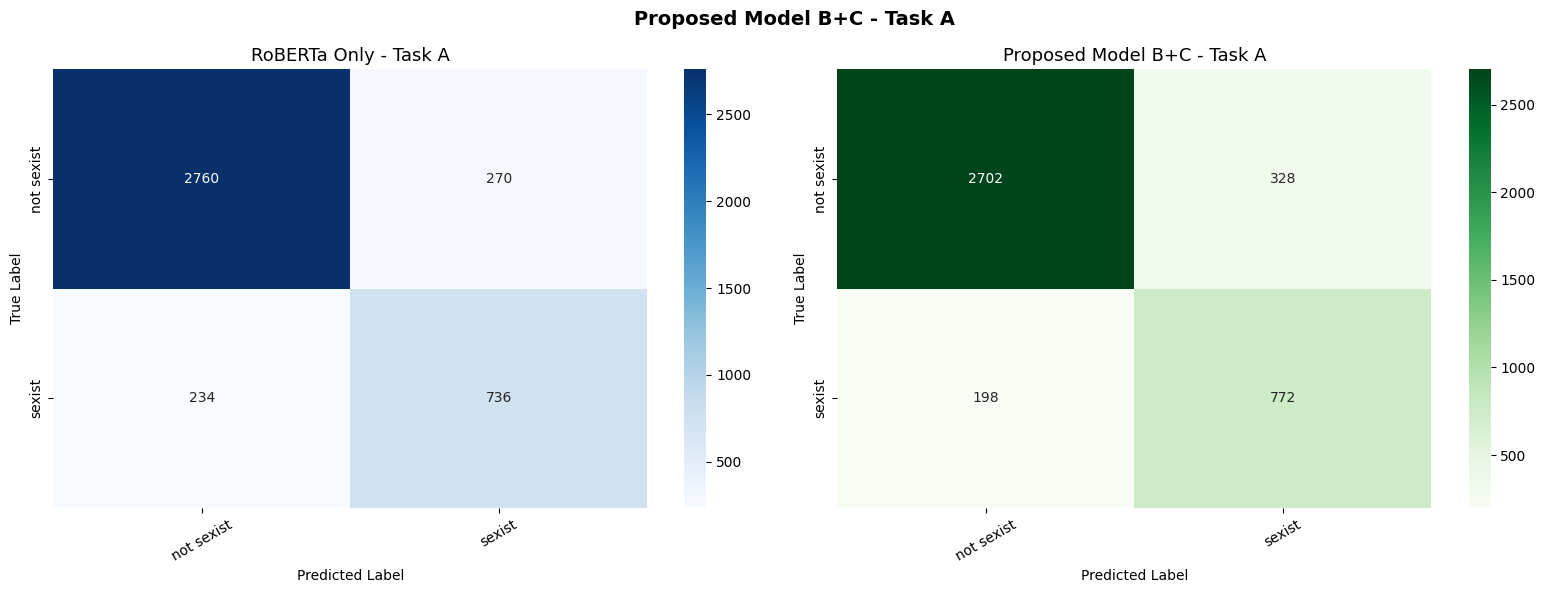

Confusion matrix saved to ../results/task_A_proposed_model_bc_confusion_matrix.png

Macro F1 Comparison - Task A:
 RoBERTa only:0.8306369663048212
Proposed Model B+C:0.8285961010500933
Delta:-0.0020408652547279083 (regression)


In [16]:
true_a, roberta_a_preds, proposed_a_preds = run_proposed_bc(task='A')
results_a = evaluate_proposed(true_a, roberta_a_preds, proposed_a_preds, task='A')

Proposed Model B+C - RoBERTa + KG v2 + LLM - Task B
KG: sexism_kg_v2.json | Retrieval: semantic similarity
Threshold: None | Fallback: RoBERTa
Running on full test set (970 samples)

Running pipeline
Progress: 0/970 | LLM called: 0 | KG hits: 0
Server busy - waiting 60s (retry 1/3)
Progress: 100/970 | LLM called: 100 | KG hits: 100
Server busy - waiting 60s (retry 1/3)
Server busy - waiting 60s (retry 1/3)
Progress: 200/970 | LLM called: 200 | KG hits: 200
Server busy - waiting 60s (retry 1/3)
Server busy - waiting 60s (retry 1/3)
Progress: 300/970 | LLM called: 300 | KG hits: 300
Server busy - waiting 60s (retry 1/3)
Progress: 400/970 | LLM called: 400 | KG hits: 400
Server busy - waiting 60s (retry 1/3)
Server busy - waiting 60s (retry 1/3)
Server busy - waiting 60s (retry 1/3)
Progress: 500/970 | LLM called: 500 | KG hits: 500
Server busy - waiting 60s (retry 1/3)
Progress: 600/970 | LLM called: 600 | KG hits: 600
Server busy - waiting 60s (retry 1/3)
Progress: 700/970 | LLM called:

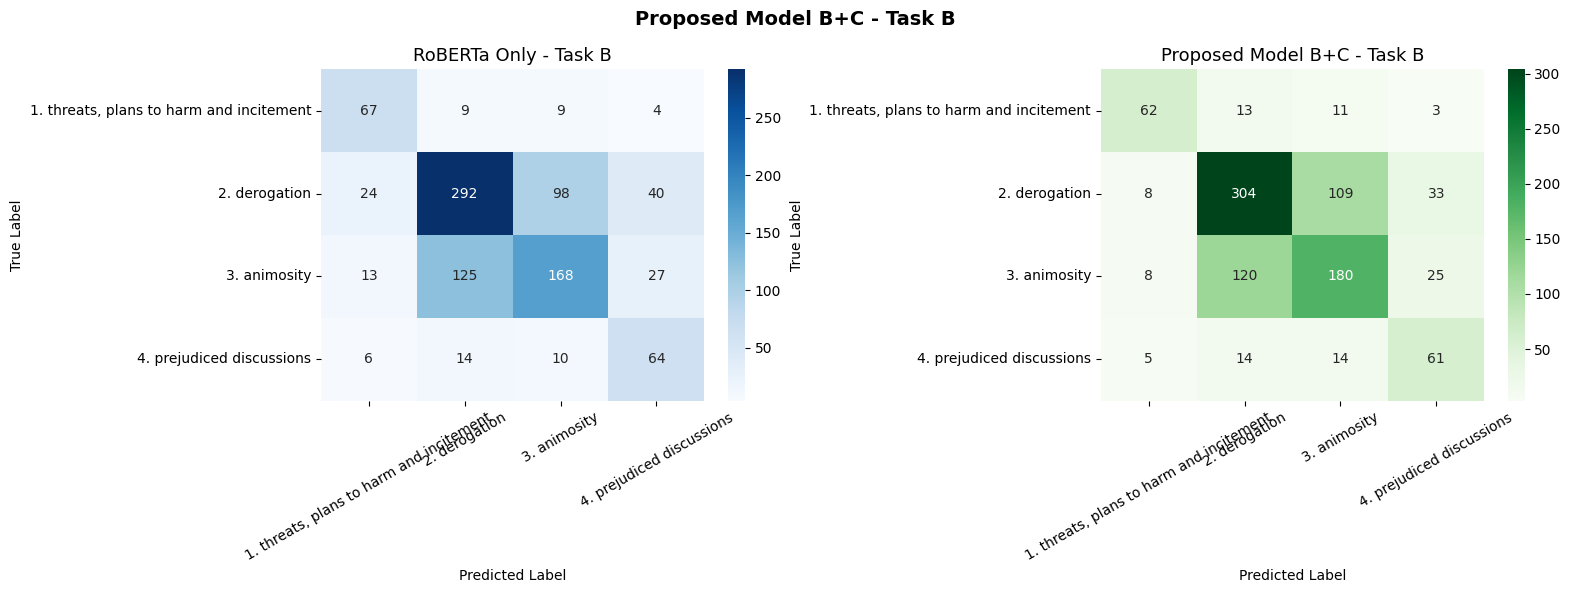

Confusion matrix saved to ../results/task_B_proposed_model_bc_confusion_matrix.png

Macro F1 Comparison - Task B:
 RoBERTa only:0.6073129918748565
Proposed Model B+C:0.6284956178168354
Delta:0.02118262594197884 (improvement)


In [17]:
true_b, roberta_b_preds, proposed_b_preds=run_proposed_bc(task='B') ## Run for Task B
results_b=evaluate_proposed(true_b, roberta_b_preds, proposed_b_preds, task='B')

Picks which 50 posts you'll evaluate

In [ ]:
import random, json
random.seed(42)

cp=os.path.join(RESULTS_DIR, 'task_B_proposedBC_checkpoint.json') ## Load B+C's saved predictions
with open(cp) as f:
    saved=json.load(f)

_, _, test_df = load_edos_data(DATA_DIR, task='B') ## Load the test set:
## zip pairs true and predicted labels; enumerate gives the position; the condition keeps only positions where they match.
correct_idx=[i for i, (t, p) in enumerate(zip(saved['true_labels'], saved['final_labels'])) if t == p]
sample_idx=random.sample(correct_idx, 50)

print(f'{len(correct_idx)} correct predictions out of {len(saved["true_labels"])}')
print(f'Sampling 50 for explanation evaluation')

607 correct predictions out of 970
Sampling 50 for explanation evaluation


Check class balance in your sample

In [15]:
from collections import Counter
sample_labels=[saved['true_labels'][i] for i in sample_idx]
print(Counter(sample_labels))

Counter({'2. derogation': 20, '3. animosity': 14, '4. prejudiced discussions': 10, '1. threats, plans to harm and incitement': 6})


Re-sample sample_idx, stratified by true class, still restricted to correct predictions

In [16]:
per_class = {}
for i, (t, p) in enumerate(zip(saved['true_labels'], saved['final_labels'])): ## a dict where each class maps to its own list of correct positions
    if t==p:
        per_class.setdefault(t, []).append(i)

## Deciding how many to take per class
classes=sorted(per_class.keys())
n_classes=len(classes)

sample_idx = []
for i, cls in enumerate(classes):
    n = 50 // n_classes + (1 if i < 50 % n_classes else 0)
    available=per_class[cls]
    if len(available)<n:
        print(f"WARNING: class '{cls}' only has {len(available)} correct predictions, wanted {n}")
    sample_idx.extend(random.sample(available, min(n, len(available))))

random.shuffle(sample_idx)

print(Counter(saved['true_labels'][i] for i in sample_idx))

Counter({'2. derogation': 13, '1. threats, plans to harm and incitement': 13, '4. prejudiced discussions': 12, '3. animosity': 12})


In [17]:
sample_df=test_df.iloc[sample_idx].copy()
sample_df['true_label']=[saved['true_labels'][i] for i in sample_idx]
sample_df=sample_df.reset_index(drop=True)
print(sample_df.shape)

(50, 9)


In [18]:
sample_df.head()

,rewire_id,text,label_sexist,label_category,label_vector,split,label,label_id,true_label
0,sexism2022_english-19056,"I actually don't think so, females have very r...",sexist,2. derogation,2.1 descriptive attacks,test,2. derogation,1,2. derogation
1,sexism2022_english-16758,TFM? Anti male agenda is very much at large. M...,sexist,4. prejudiced discussions,4.2 supporting systemic discrimination against...,test,4. prejudiced discussions,3,4. prejudiced discussions
2,sexism2022_english-404,"A woman sends that to a man and she's brave, s...",sexist,4. prejudiced discussions,4.2 supporting systemic discrimination against...,test,4. prejudiced discussions,3,4. prejudiced discussions
3,sexism2022_english-19155,That racist cunt would be in Africa eating mud...,sexist,2. derogation,2.2 aggressive and emotive attacks,test,2. derogation,1,2. derogation
4,sexism2022_english-146,That hug could turn into a false sexual assaul...,sexist,4. prejudiced discussions,4.2 supporting systemic discrimination against...,test,4. prejudiced discussions,3,4. prejudiced discussions


In [19]:
print(saved.keys())

dict_keys(['true_labels', 'roberta_labels', 'final_labels'])


In [25]:
from tqdm import tqdm
import time

EXPLANATION_PROMPT = """You are analyzing why a social media post was classified under the sexism category "{category}".

Post: "{post}"

Relevant knowledge graph context (entities and relations extracted from similar sexist posts):
{kg_context}

In 2-3 sentences, explain what makes this post an example of "{category}", grounding your explanation in the knowledge graph relations above where relevant. 
Be specific about which words or phrases in the post support this classification.
"""

explanations = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)): ## wraps the loop with a progress bar
    post=row['text']
    category=row['true_label']  # already human-readable, e.g. '2. derogation'
    triples=retrieve_triples_semantic(post, category, 'B')
    kg_context = format_kg_context(triples) if triples else "(no triples retrieved above the similarity threshold)"
    prompt=EXPLANATION_PROMPT.format(category=category, post=post, kg_context=kg_context)

    try:
        response = client.models.generate_content(model="gemini-2.5-flash-lite", contents=prompt)  # confirm this matches your actual call from Nb 05/06
        explanation_text = response.text.strip()
    except Exception as e:
        explanation_text = f"[ERROR: {e}]"

    explanations.append({
        'rewire_id': row['rewire_id'],
        'post': post,
        'true_label': category,
        'n_triples_retrieved': len(triples),
        'kg_context': kg_context,
        'explanation': explanation_text
    })
    time.sleep(1)

explanation_df = pd.DataFrame(explanations)
explanation_df.to_csv('notebook06_explanations_sample.csv', index=False)
print(f"Generated {len(explanation_df)} explanations, saved to CSV")
print(f"Posts with 0 triples retrieved: {(explanation_df['n_triples_retrieved']==0).sum()}")
explanation_df.head()

100%|██████████| 50/50 [01:31<00:00,  1.83s/it]

Generated 50 explanations, saved to CSV
Posts with 0 triples retrieved: 0


,rewire_id,post,true_label,n_triples_retrieved,kg_context,explanation
0,sexism2022_english-19056,"I actually don't think so, females have very r...",2. derogation,3,"-(female species, EXPRESSED_ANIMOSITY_TOWARDS,...","This post falls under ""2. derogation"" because ..."
1,sexism2022_english-16758,TFM? Anti male agenda is very much at large. M...,4. prejudiced discussions,3,"-(male feminists, EXPRESSED_ANIMOSITY_TOWARDS,...","This post falls under ""4. prejudiced discussio..."
2,sexism2022_english-404,"A woman sends that to a man and she's brave, s...",4. prejudiced discussions,3,"-(women, THREATENED_WITH, voice messages)(rele...","This post falls under ""4. prejudiced discussio..."
3,sexism2022_english-19155,That racist cunt would be in Africa eating mud...,2. derogation,3,"-(black bitches, EXPRESSED_ANIMOSITY_TOWARDS, ...","This post is classified as ""2. derogation"" bec..."
4,sexism2022_english-146,That hug could turn into a false sexual assaul...,4. prejudiced discussions,3,"-(daughter, EXPRESSED_ANIMOSITY_TOWARDS, hug)(...","The post exemplifies ""prejudiced discussions"" ..."


In [28]:
import re

def mean_similarity(kg_context):
    scores = re.findall(r'relevance: ([\d.]+)', kg_context)
    scores = [float(s) for s in scores]
    return sum(scores) / len(scores) if scores else None

explanation_df['mean_triple_similarity'] = explanation_df['kg_context'].apply(mean_similarity)

print(explanation_df.groupby('true_label')['mean_triple_similarity'].mean().round(3))

true_label
1. threats, plans to harm and incitement    0.493
2. derogation                               0.536
3. animosity                                0.431
4. prejudiced discussions                   0.548
Name: mean_triple_similarity, dtype: float64
